In [9]:
#Load and inspect
import pandas as pd
df=pd.read_csv(r"C:\Users\Admin\Desktop\My stuff\Programming\ML\Projects\spotify-recommendation-system\data\raw\dataset.csv")
print(df.shape)
df.head()

(114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [16]:
#Check for missing values
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [15]:
#Check for and remove duplicates
print(df.duplicated(subset='track_id').sum())
df=df.drop_duplicates(subset='track_id')

0


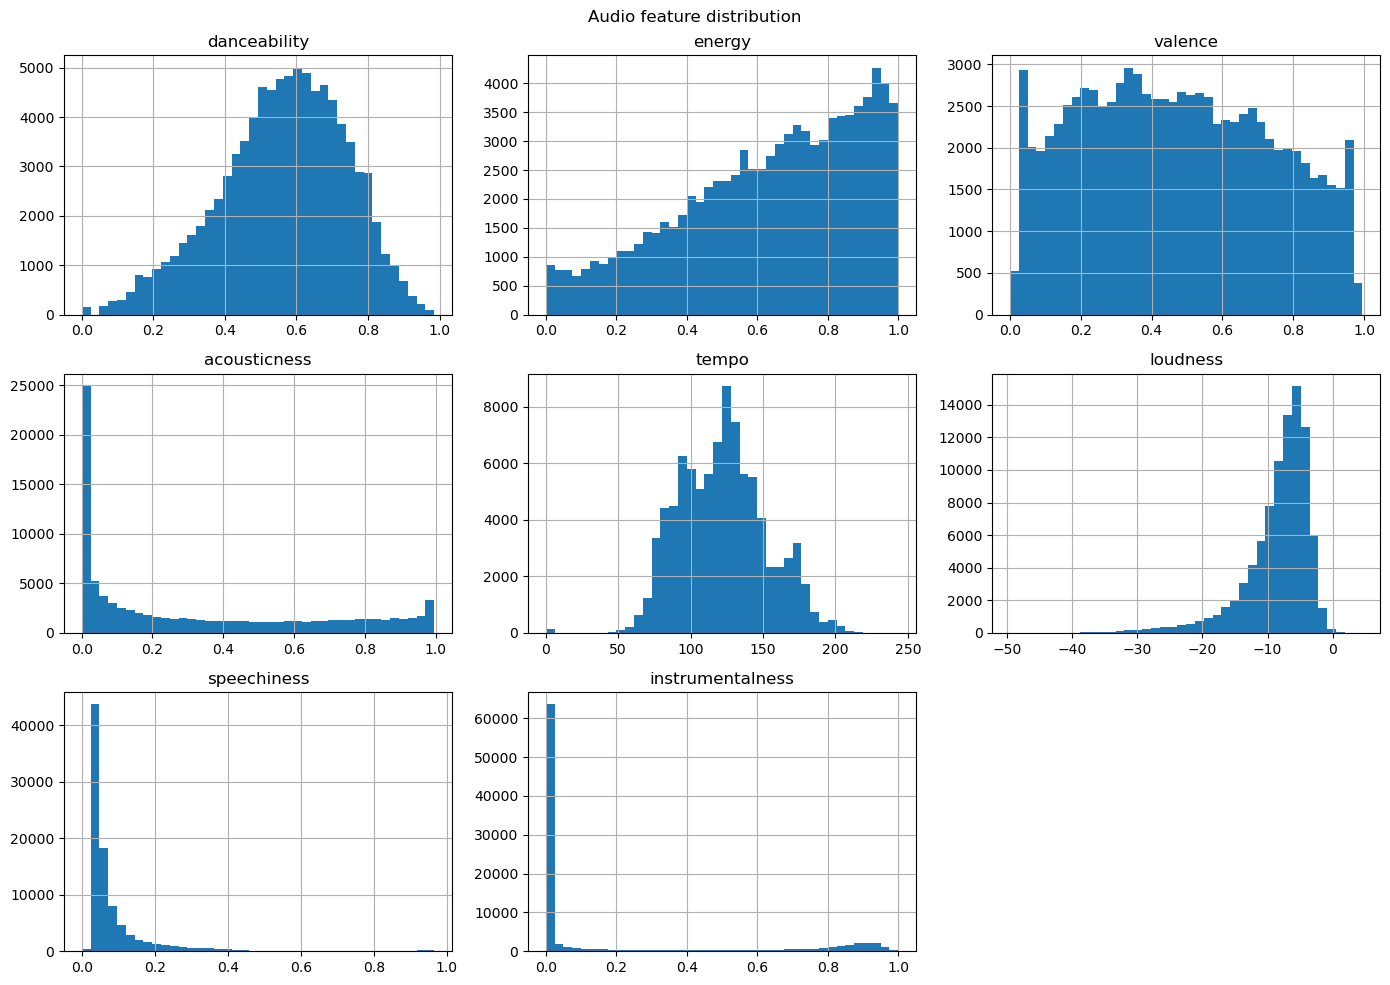

In [19]:
#Visualize distributions
import matplotlib.pyplot as plt
import seaborn as sns

audio_features=['danceability','energy','valence','acousticness','tempo','loudness','speechiness','instrumentalness']
df[audio_features].hist(figsize=(14,10), bins=40)
plt.suptitle('Audio feature distribution')
plt.tight_layout()
plt.show()

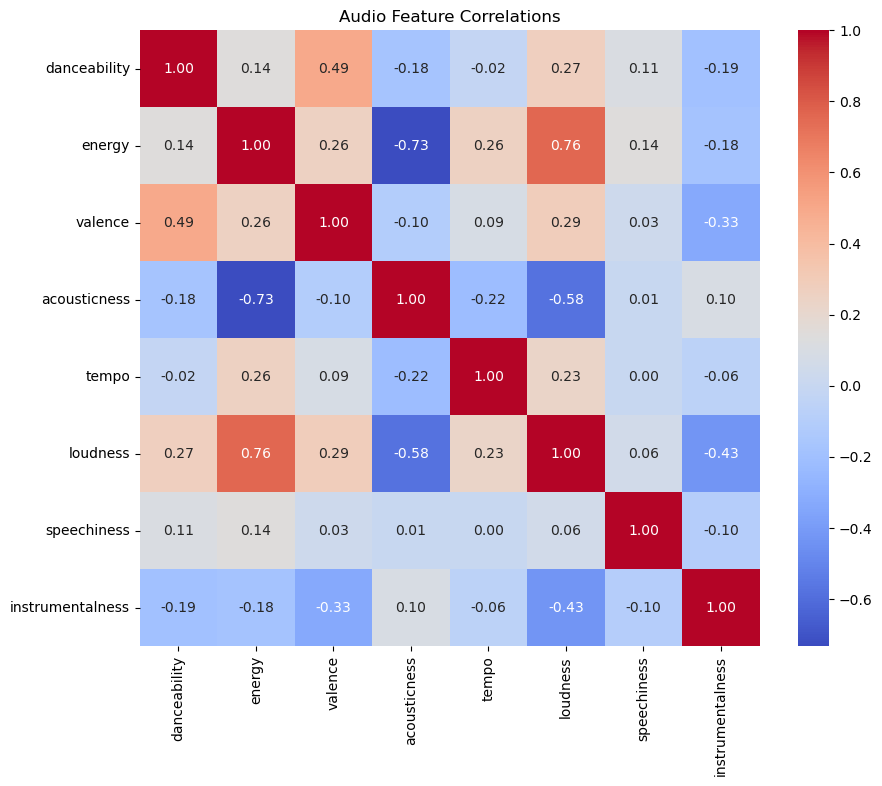

In [20]:
#Correlation heatmap
# Concept: which features move together? e.g. energy & loudness tend to correlate
plt.figure(figsize=(10, 8))
sns.heatmap(df[audio_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Audio Feature Correlations')
plt.show()


In [23]:
df.to_csv(r"C:\Users\Admin\Desktop\My stuff\Programming\ML\Projects\spotify-recommendation-system\data\processed\tracks_clean.csv", index=False)